# Load QICK

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from qick.pyro import make_proxy
import Pyro4

from QickworkspaceV2.config.system_cfg import DATA_PATH, config_list
from QickworkspaceV2.tools.system_tool import ExperimentConfig
from QickworkspaceV2.core.base_experiment import BaseExperiment
from QickworkspaceV2.experiments_mux import MuxAllXY, MuxAutoRB, MuxOneTone, MuxPowerRabi, MuxPunchout, MuxRamsey, MuxRB, MuxRandomizedBenchmarking, MuxSingleShotGE, MuxSingleShotGEOpt, MuxStateTomography, MuxT1, MuxTOF, MuxTomography, MuxTwoTone

Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
ns_host = "192.168.10.82"
ns_port = 8888
proxy_name = "myqick"

soc, soccfg = make_proxy(ns_host=ns_host, ns_port=ns_port, proxy_name=proxy_name)
BaseExperiment.setup(soc, soccfg, DATA_PATH)
print(soccfg)

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_bff646b76c5e4e518b71a66a256d98d2@192.168.10.82:35471
QICK running on ZCU216, software version 0.2.381

Firmware configuration (built Sun Aug 10 18:48:22 2025):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 32768 complex samples (3.419 us)
		32-

# Instrument connect

In [29]:
from QickworkspaceV2.instruments import BaseInstrumentManager

inst = BaseInstrumentManager()

# Fill these before running. SGS100A/MG3692 accept either plain IP or full VISA string.
# Q1_FLUX_ADDR = "USB0::0x0B21::0x0039::91S522309::INSTR"
# Q2_FLUX_ADDR = ""  # Optional second Yoko; leave empty to skip
MG3692_ADDR = "192.168.10.182"

# Q1_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}
# Q2_FLUX_LIMITS = {"current": (-3e-3, 3e-3), "voltage": (-1.0, 1.0)}

# q1_flux = inst.add_yoko(
#     "q1_flux",
#     Q1_FLUX_ADDR,
#     limits=Q1_FLUX_LIMITS,
#     current_ramp_step=1e-8,
#     voltage_ramp_step=1e-5,
#     ramp_interval=0.01,
# )

# q2_flux = None
# if Q2_FLUX_ADDR:
#     q2_flux = inst.add_yoko(
#         "q2_flux",
#         Q2_FLUX_ADDR,
#         limits=Q2_FLUX_LIMITS,
#         current_ramp_step=1e-8,
#         voltage_ramp_step=1e-5,
#         ramp_interval=0.01,
#     )

# lo = inst.add_mg3692("LO", MG3692_ADDR)
# # inst.set_value('LO', 'frequency', 6e9)
# inst.status

In [103]:
config_all = ExperimentConfig(config_list)
config_all.qubit_names()

['Q1', 'Q2', 'Q3', 'Q4']

In [104]:
arm_qubit = ["Q1", "Q3"]

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)

summary_keys = [
    "qubit_names",
    "active_slots",
    "mask",
    "res_ch",
    "ro_chs",
    "active_ro_chs",
    "res_freqs",
    "res_gains",
    "res_phases",
    "ro_phases",
    "qb_ch",
    "qb_freq_ge",
    "pi_gain_ge",
    "mixer_freq",
    "LO_ext",
    "trig_time",
]

for key in summary_keys:
    print(f"{key}: {run_cfg.get(key)}")

qubit_names: ['Q1', 'Q3']
active_slots: [0, 2]
mask: [0, 1, 2, 3]
res_ch: 4
ro_chs: [2, 4]
active_ro_chs: [2, 4]
res_freqs: [718.9875060000004, 740, 815, 890]
res_gains: [1, 0, 1, 0]
res_phases: [0, 0, 0, 0]
ro_phases: [0, 0, 0, 0]
qb_ch: [0, 0, 2, 0]
qb_freq_ge: [3628.177476, 3620.80596, 3128.836071, 3312.01532]
pi_gain_ge: [0.213013, 0.1, 0.328157, 0.1]
mixer_freq: 767
LO_ext: 6000
trig_time: 0.75


# TOF

The mux mask is fixed to the number of configured qubit slots. Non-armed qubits keep their frequency slot but get zero readout gain.

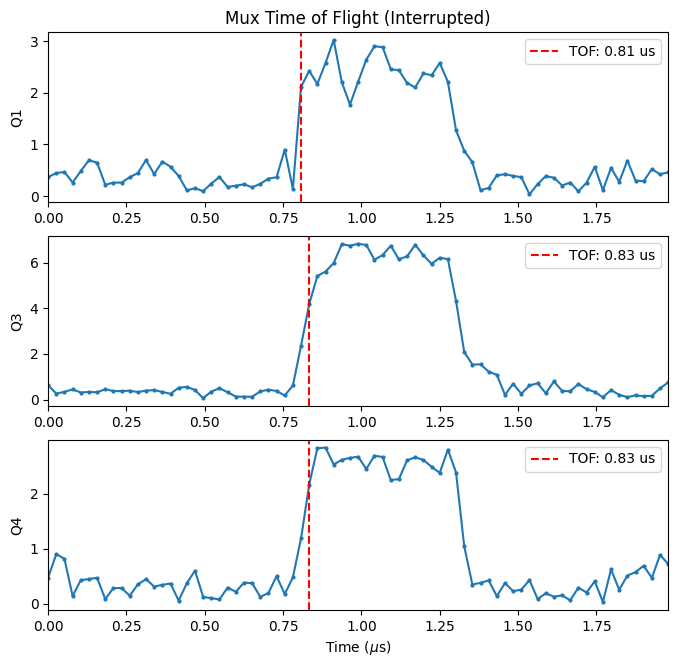

{'Q1': (0.8072916666666667, None),
 'Q3': (0.8333333333333334, None),
 'Q4': (0.8333333333333334, None)}

In [ ]:
config_all.update("res_gain_ge", 1)
run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)

run_cfg.update(
    [
        ("res_length", 0.5),
        ("ro_length",2),
        ("relax_delay", 0),
    ]
)
tof = MuxTOF(run_cfg)
# tof.prog_asm()
result = tof.run(py_avg=1000)
result.fit_result

## Mux OneTone

Sweep each active resonator over a 20 MHz span around its configured center frequency.

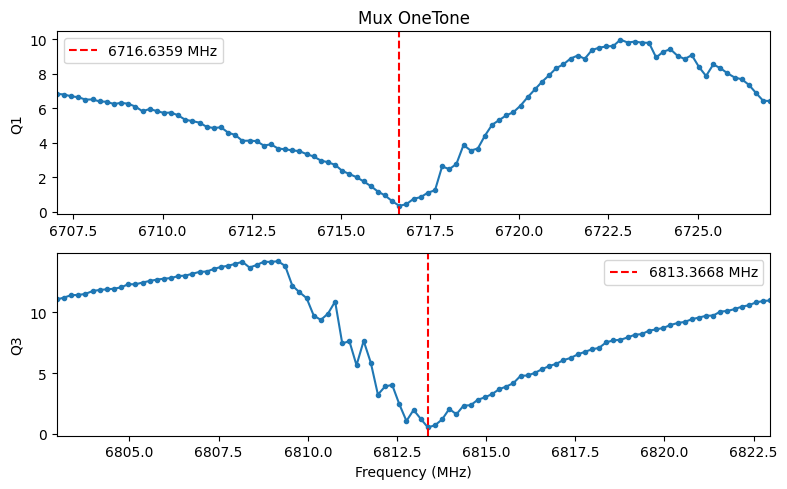

{'Q1_res_freq_mhz': (6716.635856, None),
 'Q3_res_freq_mhz': (6813.366771, None)}

In [166]:
SPAN = 10
STEPS = 101

config_all.update("res_gain_ge", 0.8)
run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("res_freq_ge", np.linspace(-SPAN, SPAN, STEPS)),
        ("relax_delay", 0),
    ]
)

onetone = MuxOneTone(run_cfg)
onetone_result = onetone.run(py_avg=3, span=20.0, steps=101, iq_process="abs", plot=True)

f_res = [
    onetone_result.fit_result[f"{q}_res_freq_mhz"][0]
    for q in arm_qubit
]

config_all.update(
    "res_freq_ge",
    f_res,
    q_index=arm_qubit,
)

onetone_result.fit_result


In [168]:
PUNCH_SPAN = 20.0
PUNCH_STEPS = 101
PUNCH_GAINS = np.linspace(0.0, 1.0, 21)

arm_qubit = ["Q1", "Q3"]

config_all.update("res_length", 5)
config_all.update("ro_length", 5)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("relax_delay", 0),
    ]
)

punchout = MuxPunchout(run_cfg)
punchout_result = punchout.run(
    py_avg=5,
    span=PUNCH_SPAN,
    f_steps=PUNCH_STEPS,
    gains=PUNCH_GAINS,
    iq_process="abs",
    plot=True,
)
punchout_result.fit_result

Gain:   0%|          | 0/21 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

...

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency:   0%|          | 0/101 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "c:\Users\cluster\anaconda3\envs\qick2env\lib\site-packages\IPython\core\interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\cluster\AppData\Local\Temp\ipykernel_29856\2865538888.py", line 23, in <module>
    punchout_result = punchout.run(
  File "c:\Users\cluster\Desktop\QickworksaceV2_proj-test_mux\QickworkspaceV2\experiments_mux\punchout.py", line 164, in run
    self._normalize_per_power(plot_data) if normalize_per_power else plot_data
TypeError: _normalize_per_power() takes 1 positional argument but 2 were given


## Mux TwoTone

Drive one active qubit at a time while reading out the mux channels.

In [107]:
config_all.update(
    "qb_freq_ge",
    [3620, 3125],
    q_index=arm_qubit,
)

  0%|          | 0/50 [00:00<?, ?it/s]

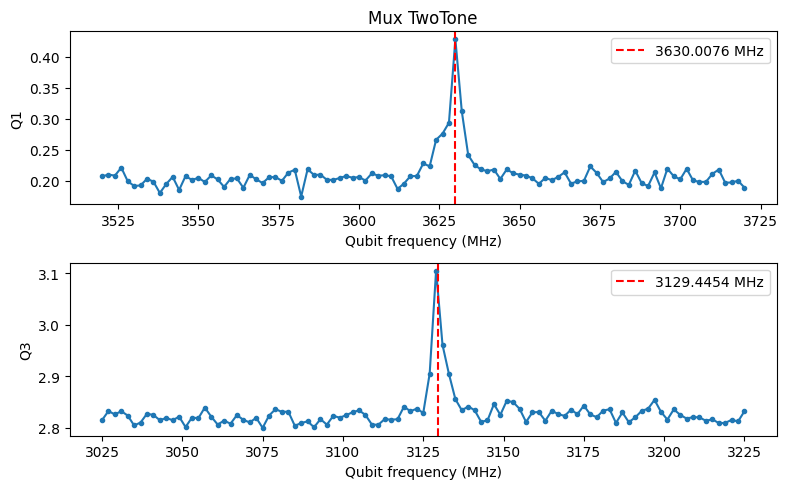

{'Q1_qb_freq_ge_mhz': (3630.007557, None),
 'Q3_qb_freq_ge_mhz': (3129.445381, None)}

In [108]:
START_FREQ = -100
STOP_FREQ = 100
QB_STEPS = 101

arm_qubit = ["Q1", "Q3"]

config_all.update("res_gain_ge", 0.4, q_index=arm_qubit)

config_all.update("qb_ch", [0, 2], q_index=arm_qubit)
config_all.update("qb_gain_ge", 0.3, q_index=arm_qubit)
config_all.update("qb_flat_top_length_ge", 5, q_index=arm_qubit)
config_all.update("pulse_type", "flat_top", q_index=arm_qubit)
config_all.update("sigma_ge", 0.05, q_index=arm_qubit)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_freq", START_FREQ),
        ("stop_freq", STOP_FREQ),
        ("steps", QB_STEPS),
        ("relax_delay", 50),
    ]
)

twotone = MuxTwoTone(run_cfg)
twotone_result = twotone.run(py_avg=50, iq_process="abs", plot=True)
twotone_result.fit_result

In [109]:
f_qb = [
    twotone_result.fit_result[f"{q}_qb_freq_ge_mhz"][0]
    for q in arm_qubit
]

config_all.update(
    "qb_freq_ge",
    f_qb,
    q_index=arm_qubit,
)

## Mux Power Rabi

Sweep qubit drive gain with mux readout on the armed qubits.

  0%|          | 0/30 [00:00<?, ?it/s]

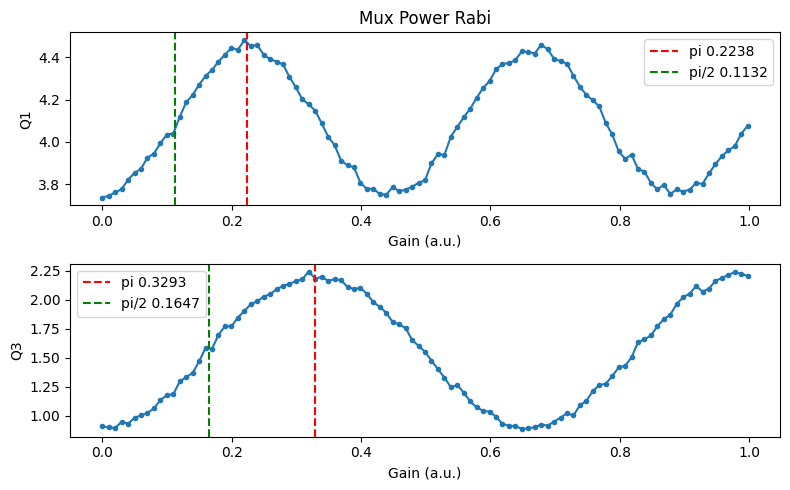

{'Q1_pi_gain': (0.22385, None),
 'Q1_pi2_gain': (0.113169, None),
 'Q3_pi_gain': (0.329312, None),
 'Q3_pi2_gain': (0.164724, None)}

In [147]:
START_GAIN = 0.0
STOP_GAIN = 1.0
GAIN_STEPS = 101

arm_qubit = ["Q1", "Q3"]


config_all.update("pulse_type", "arb", q_index=arm_qubit)
config_all.update("sigma_ge", 0.1, q_index=arm_qubit)
config_all.update("relax_delay", 300, q_index=arm_qubit)
run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_gain", START_GAIN),
        ("stop_gain", STOP_GAIN),
        ("steps", GAIN_STEPS),
    ]
)

power_rabi = MuxPowerRabi(run_cfg)
power_rabi_result = power_rabi.run(py_avg=30, iq_process="abs", plot=True)
power_rabi_result.fit_result

In [148]:
pi_gain = [
    power_rabi_result.fit_result[f"{q}_pi_gain"][0]
    for q in arm_qubit
]
pi2_gain = [
    power_rabi_result.fit_result[f"{q}_pi2_gain"][0]
    for q in arm_qubit
]

config_all.update("pi_gain_ge", pi_gain, q_index=arm_qubit)
config_all.update("pi2_gain_ge", pi2_gain, q_index=arm_qubit)

  0%|          | 0/20 [00:00<?, ?it/s]

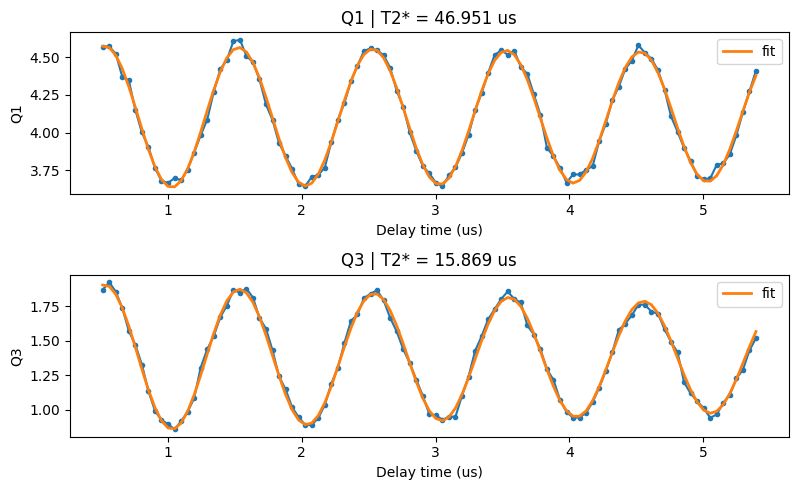

{'Q1_T2r_us': (46.950692, 13.392841453241461),
 'Q1_fit_freq_MHz': (0.999001, 0.0009554800516522309),
 'Q1_detune_MHz': (-0.000999, None),
 'Q1_corrected_freq_MHz': (3628.147557, None),
 'Q3_T2r_us': (15.868997, 1.5516790713816087),
 'Q3_fit_freq_MHz': (0.992913, 0.0009726096401355535),
 'Q3_detune_MHz': (-0.007087, None),
 'Q3_corrected_freq_MHz': (3128.805381, None)}

In [153]:
START_WAIT = 0.0
STOP_WAIT = 5.0
WAIT_STEPS = 101

arm_qubit = ["Q1", "Q3"]


config_all.update("virtual_detune", 1, q_index=arm_qubit)

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_wait", START_WAIT),
        ("stop_wait", STOP_WAIT),
        ("steps", WAIT_STEPS),
        ("relax_delay", 300),
    ]
)

ramsey = MuxRamsey(run_cfg)
ramsey_result = ramsey.run(py_avg=20, iq_process="abs", plot=True)
ramsey_result.fit_result

In [154]:
corrections = ramsey.correct_detune()
update_qubits = [
    q for q in arm_qubit
    if q in corrections and corrections[q]["status"] == "corrected"
]

new_qb_freq = [
    corrections[q]["new_qb_freq_ge"]
    for q in update_qubits
]

if update_qubits:
    config_all.update("qb_freq_ge", new_qb_freq, q_index=update_qubits)

corrections

Q1: detune < 5 kHz
Q3: detune error -0.01000 MHz, qb_freq_ge -> 3128.80538 MHz


{'Q1': {'old_qb_freq_ge': 3628.147557,
  'new_qb_freq_ge': 3628.147557,
  'fit_freq_MHz': 0.999001,
  'virtual_detune_MHz': 1.0,
  'detune_MHz': -0.0009989999999999721,
  'detune_error_MHz': -0.0,
  'status': 'detune < 5 kHz'},
 'Q3': {'old_qb_freq_ge': 3128.795381,
  'new_qb_freq_ge': 3128.805381,
  'fit_freq_MHz': 0.992913,
  'virtual_detune_MHz': 1.0,
  'detune_MHz': -0.0070869999999999544,
  'detune_error_MHz': -0.01,
  'status': 'corrected'}}

  0%|          | 0/20 [00:00<?, ?it/s]

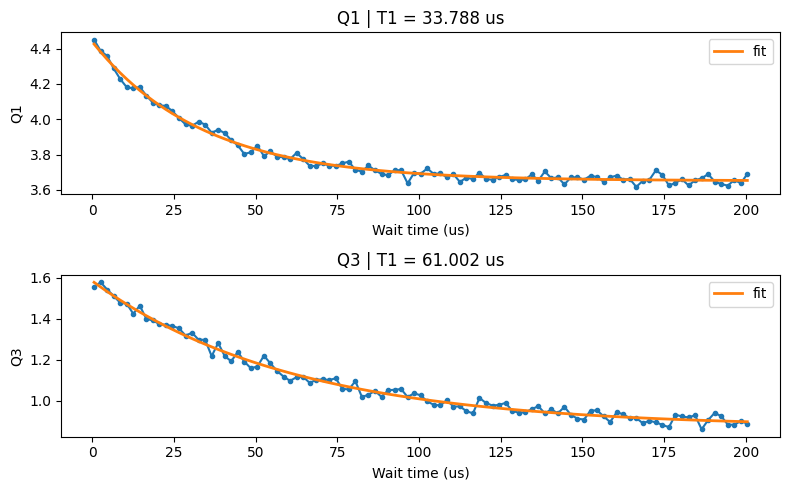

{'Q1_T1_us': (33.788087, None), 'Q3_T1_us': (61.001521, None)}

In [155]:
START_WAIT = 0.0
STOP_WAIT = 200.0
WAIT_STEPS = 101




run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("start_wait", START_WAIT),
        ("stop_wait", STOP_WAIT),
        ("steps", WAIT_STEPS),
        ("relax_delay", 300),
    ]
)

t1 = MuxT1(run_cfg)
t1_result = t1.run(py_avg=20, iq_process="abs", plot=True)
t1_result.fit_result

  0%|          | 0/5000 [00:00<?, ?it/s]

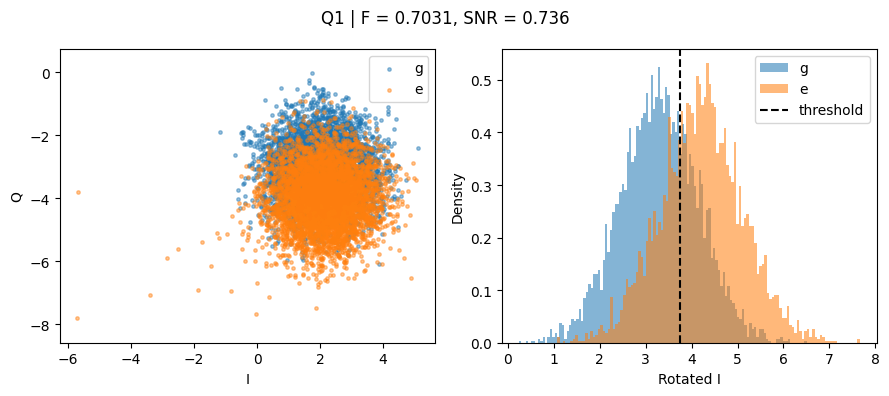

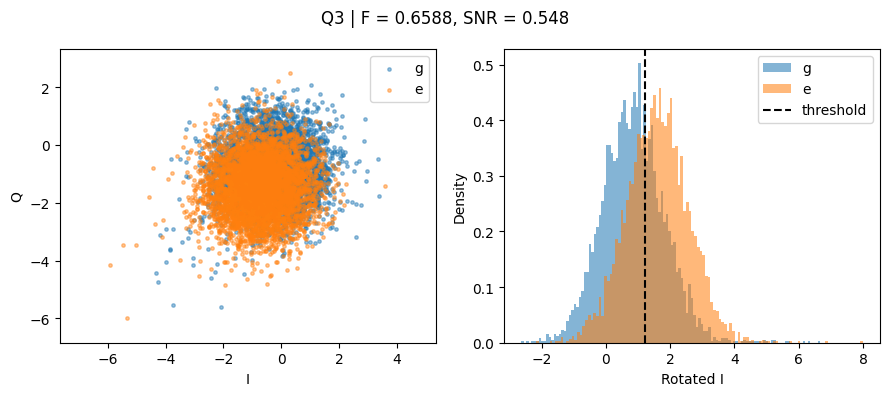

{'Q1_fidelity': (0.7031, None),
 'Q1_threshold': (3.751675, None),
 'Q1_rotation_deg': (83.367689, None),
 'Q1_snr': (0.736395, None),
 'Q3_fidelity': (0.6588, None),
 'Q3_threshold': (1.229328, None),
 'Q3_rotation_deg': (126.891826, None),
 'Q3_snr': (0.548344, None)}

In [162]:
SHOTS = 5000


# config_all.update("res_gain_ge", 1, q_index=arm_qubit)
# config_all.update("res_length", 10)
config_all.update("ro_length", 5)
arm_qubit= ["Q1","Q3"]
# arm_qubit= ["Q1"]
run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("shots", SHOTS),
        ("relax_delay", 500),
    ]
)

single_shot = MuxSingleShotGE(run_cfg)
single_shot_result = single_shot.run(plot=True)
single_shot_result.fit_result

SingleShot optimize:   0%|          | 0/60 [00:00<?, ?it/s]

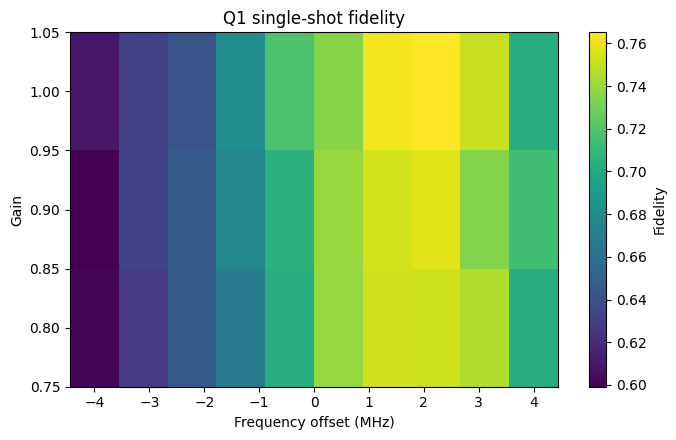

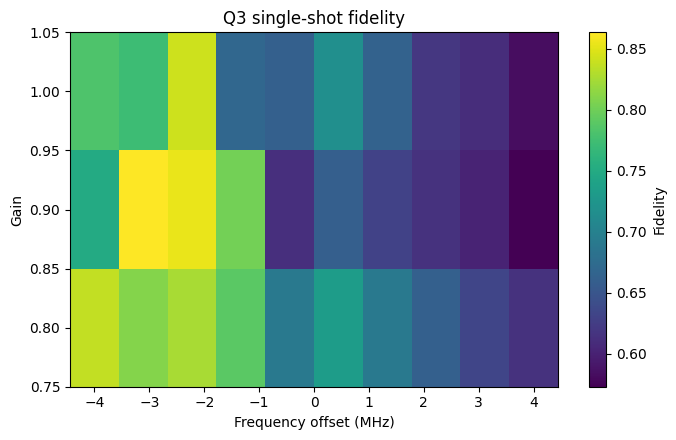

{'Q1_best_fidelity': (0.765167, None),
 'Q1_best_length': (7.6, None),
 'Q1_best_gain': (1.0, None),
 'Q1_best_res_freq_mhz': (6721.209728, None),
 'Q1_threshold': (3.247956, None),
 'Q1_rotation_deg': (-102.433582, None),
 'Q1_snr': (0.988962, None),
 'Q3_best_fidelity': (0.8635, None),
 'Q3_best_length': (7.6, None),
 'Q3_best_gain': (0.9, None),
 'Q3_best_res_freq_mhz': (6810.888889, None),
 'Q3_threshold': (-7.485036, None),
 'Q3_rotation_deg': (3.553158, None),
 'Q3_snr': (1.276005, None)}

In [160]:
SHOTS = 3000

arm_qubit = ["Q1", "Q3"]

config_all.update("res_length", 10)


run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("shots", SHOTS),
        ("relax_delay", 500),
    ]
)

sweep_para = {
    "length": np.linspace(7.5, 7.6, 2),
    "gain": np.linspace(0.8, 1, 3),
    "freq_offset": np.linspace(-4.0, 4.0, 10),
}

ss_opt = MuxSingleShotGEOpt(run_cfg)
ss_opt_result = ss_opt.run(shots=SHOTS, sweep_para=sweep_para, plot=True)
ss_opt_result.fit_result

In [161]:
best_res_freq = [
    ss_opt_result.fit_result[f"{q}_best_res_freq_mhz"][0]
    for q in arm_qubit
]

best_gain = [
    ss_opt_result.fit_result[f"{q}_best_gain"][0]
    for q in arm_qubit
]

best_len = [
    ss_opt_result.fit_result[f"{q}_best_length"][0]
    for q in arm_qubit
]

best_len_common = min(best_len)
config_all.update("res_length", best_len_common)
config_all.update("ro_length", best_len_common)

## Mux AllXY

Run the 21 AllXY gate pairs on every armed qubit with mux readout.


Mux AllXY:   0%|          | 0/21 [00:00<?, ?it/s]

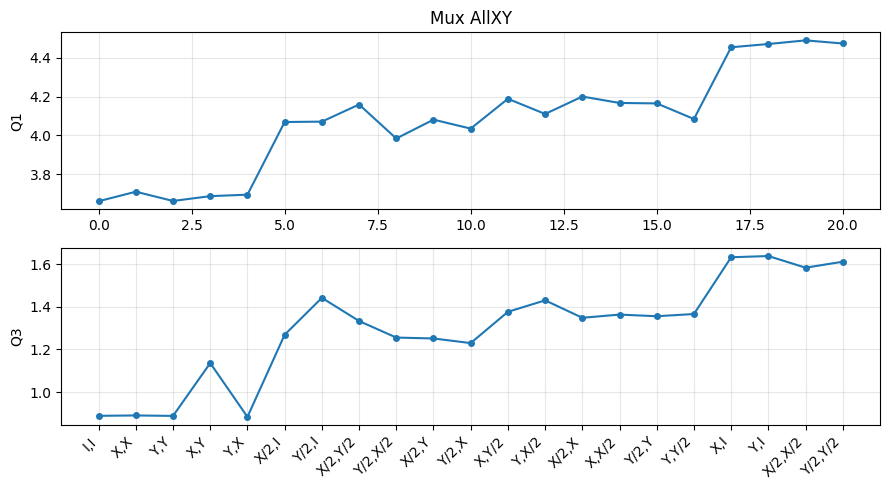

{'Q1_allxy_error': (0.249548, None), 'Q3_allxy_error': (0.262248, None)}

In [163]:
arm_qubit = ["Q1", "Q3"]

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("relax_delay", 500),
    ]
)

allxy = MuxAllXY(run_cfg)
allxy_result = allxy.run(py_avg=20, iq_process="abs", plot=True)
allxy_result.fit_result


## Mux Tomography

Measure X/Y/Z tomography axes for each armed qubit. Use `prep_pulse_name` to choose the prepared state.


Mux Tomography:   0%|          | 0/3 [00:00<?, ?it/s]

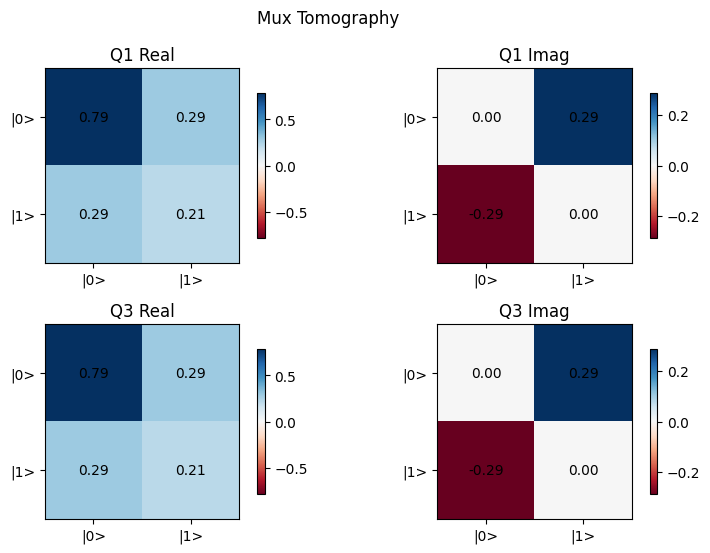

{'Q1_expect_X': (1.0, None),
 'Q1_expect_Y': (-1.0, None),
 'Q1_expect_Z': (1.0, None),
 'Q1_purity': (1.0, None),
 'Q3_expect_X': (1.0, None),
 'Q3_expect_Y': (-1.0, None),
 'Q3_expect_Z': (1.0, None),
 'Q3_purity': (1.0, None)}

In [143]:
arm_qubit = ["Q1", "Q3"]

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("relax_delay", 100),
    ]
)

tomography = MuxTomography(run_cfg)
tomo_result = tomography.run(py_avg=20, prep_pulse_name="x90", plot=True)
tomo_result.fit_result


## Mux RB

Run standard RB on the armed qubits. For interleaved RB, set `interleaved_gate="X"`, `"Y"`, `"X/2"`, or `"Y/2"`.


Mux RB average:   0%|          | 0/5 [00:00<?, ?it/s]

Depth:   0%|          | 0/6 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[fitrb] p=0.917982  a=-0.4135  b=1.7386
[fitrb] σ(p)=2.50e-01  σ(a)=4.78e-01  σ(b)=3.13e-01
[fitrb] p=0.925606  a=-0.1787  b=0.4651
[fitrb] σ(p)=1.36e-01  σ(a)=1.22e-01  σ(b)=8.76e-02


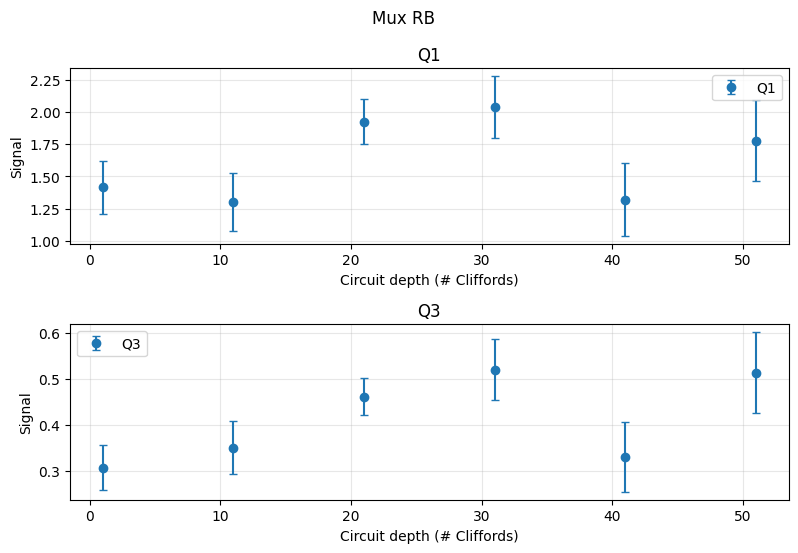

{}

In [144]:
arm_qubit = ["Q1", "Q3"]

run_cfg = config_all.muxconfig(
    arm_qubit,
    mux_gen=4,
    mux_ro_ch_start=2,
    LO_ext=6000,
)
run_cfg.update(
    [
        ("relax_delay", 500),
    ]
)

rb = MuxRandomizedBenchmarking(run_cfg)
rb_result = rb.run(
    py_avg=5,
    max_circuit_depth=61,
    delta_clifford=10,
    number_sample=10,
    interleaved_gate=None,
    seed=1234,
    iq_process="abs",
    plot=True,
)
rb_result.fit_result


Mux AutoRB:   0%|          | 0/5 [00:00<?, ?it/s]

Mux RB average:   0%|          | 0/5 [00:00<?, ?it/s]

Depth:   0%|          | 0/6 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[fitrb] p=0.806109  a=0.5914  b=1.4776
[fitrb] σ(p)=3.54e-01  σ(a)=3.64e-01  σ(b)=1.14e-01
[fitrb] p=0.999364  a=-1.6690  b=2.0625
[fitrb] σ(p)=2.60e-01  σ(a)=6.70e+02  σ(b)=6.70e+02


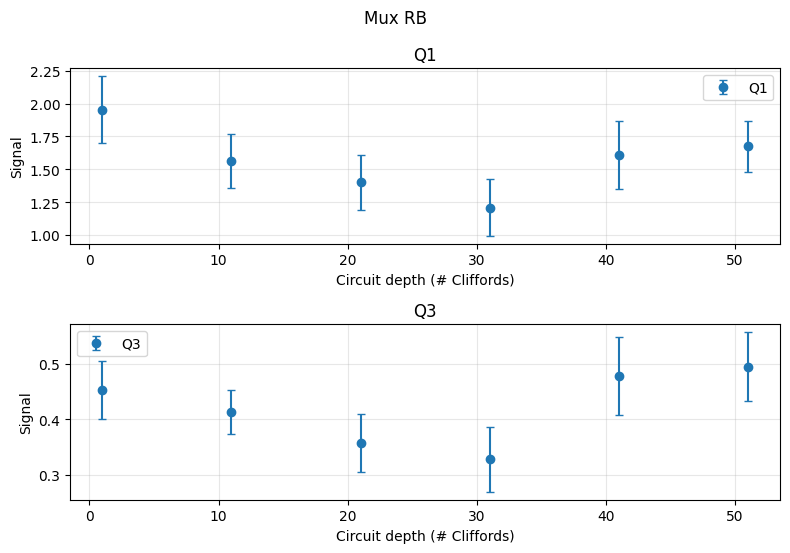

Mux RB average:   0%|          | 0/5 [00:00<?, ?it/s]

Depth:   0%|          | 0/6 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[fitrb] p=0.998410  a=-4.7341  b=5.9864
[fitrb] σ(p)=8.42e-02  σ(a)=2.41e+02  σ(b)=2.41e+02
[fitrb] p=0.997865  a=-1.8172  b=2.1005
[fitrb] σ(p)=3.56e-02  σ(a)=2.87e+01  σ(b)=2.88e+01


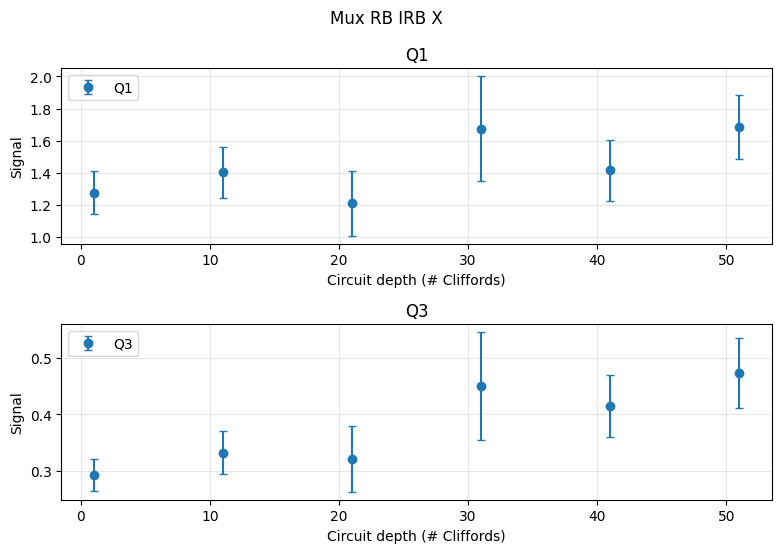

Mux RB average:   0%|          | 0/5 [00:00<?, ?it/s]

Depth:   0%|          | 0/6 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[fitrb] p=1.000000  a=0.8273  b=0.9169
[fitrb] σ(p)=9.50e-03  σ(a)=1.22e-01  σ(b)=1.22e-01
[fitrb] p=0.979864  a=-0.1894  b=0.6708
[fitrb] σ(p)=1.25e-01  σ(a)=6.88e-01  σ(b)=7.32e-01


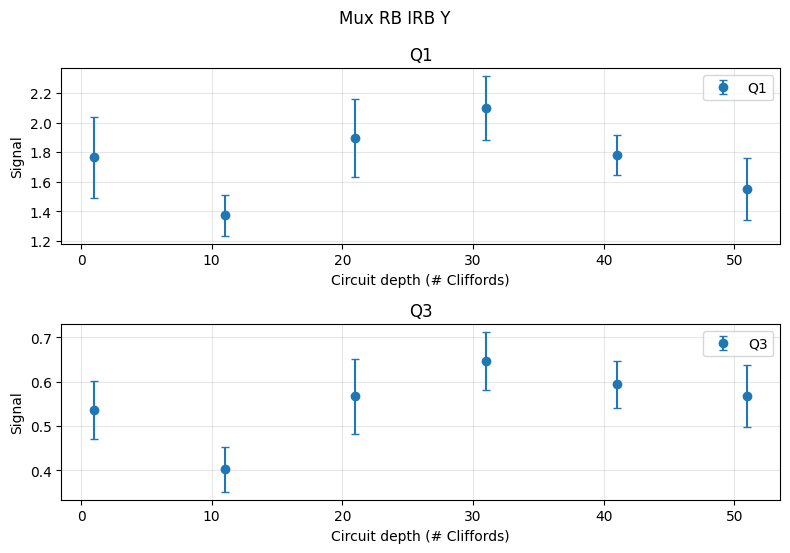

Mux RB average:   0%|          | 0/5 [00:00<?, ?it/s]

Depth:   0%|          | 0/6 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[fitrb] p=0.999965  a=3.2163  b=-1.7765
[fitrb] σ(p)=7.36e+00  σ(a)=6.78e+05  σ(b)=6.78e+05
[fitrb] p=0.787352  a=-0.1050  b=0.4322
[fitrb] σ(p)=8.58e-01  σ(a)=1.41e-01  σ(b)=3.81e-02


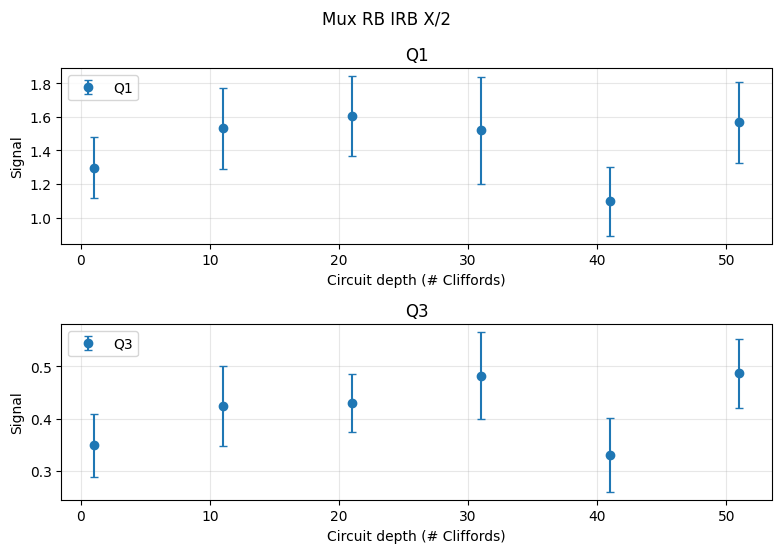

Mux RB average:   0%|          | 0/5 [00:00<?, ?it/s]

Depth:   0%|          | 0/6 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

...

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Samples:   0%|          | 0/10 [00:00<?, ?it/s]

[fitrb] p=0.999336  a=4.6174  b=-2.9054
[fitrb] σ(p)=2.39e-01  σ(a)=1.63e+03  σ(b)=1.63e+03
[fitrb] p=0.202198  a=-0.4014  b=0.4435
[fitrb] σ(p)=1.12e+05  σ(a)=2.21e+05  σ(b)=2.29e-02


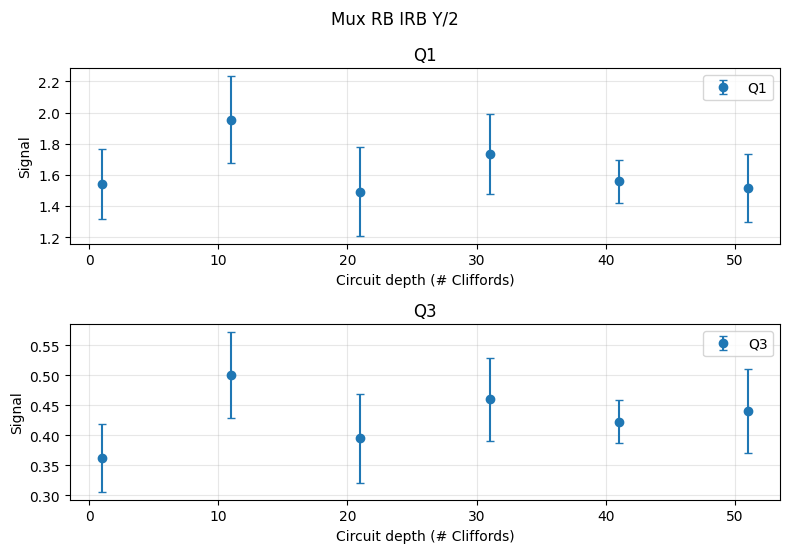

Mux AutoRB Summary
[ref]
[X]
[Y]
[X/2]
[Y/2]


In [145]:
auto_rb = MuxAutoRB(run_cfg)
auto_rb_results = auto_rb.run(
    py_avg=5,
    max_circuit_depth=61,
    delta_clifford=10,
    number_sample=10,
    interleaved_gates=["X", "Y", "X/2", "Y/2"],
    seed=1234,
    iq_process="abs",
    plot=True,
)
print(auto_rb.summary())
